import pandas as pd
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv('cardio_train.csv', sep=';')

In [3]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [4]:
##how many null values
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [5]:
##how many duplicates
df.duplicated().sum()

0

In [6]:
##convert the age into years
df['age_years'] = df['age'] / 365.25

In [7]:
##how many females have heart problem?
df[(df['gender'] == 1) & (df['cardio'] == 1)].shape[0]

22616

In [8]:
##how many non-smokers have heart problem?
df[(df['smoke'] == 0) & (df['cardio'] == 1)].shape[0]

32050

In [9]:
##how many person have high cholesterol & not heart problem?
df[(df['cholesterol'] > 1) & (df['cardio'] == 0)].shape[0]


5691

In [10]:
##how many person have alcohol & not heart problem?
df[(df['alco'] == 1) & (df['cardio'] == 0)].shape[0]


1941

In [11]:
## how many elders don't have heart problem?
df[(df['age_years'] >= 60) & (df['cardio'] == 0)].shape[0]


4215

In [12]:
## how many teens have heart problem?
df[(df['age_years'] < 20) & (df['cardio'] == 1)].shape[0]

0

In [13]:
##removing outliers for model training
df = df[(df['ap_hi'] <= 250) & (df['ap_hi'] >= 60)]
df = df[(df['ap_lo'] <= 150) & (df['ap_lo'] >= 40)]
df = df[df['ap_hi'] > df['ap_lo']]

In [14]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50.357290
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55.381246
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51.627652
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48.249144
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47.841205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,52.676249
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,61.878166
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,52.199863
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,61.412731


In [15]:
##adding bmi for easy estimation
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)

In [16]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50.357290,21.967120
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55.381246,34.927679
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51.627652,23.507805
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48.249144,28.710479
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47.841205,23.011177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,52.676249,26.927438
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,61.878166,50.472681
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,52.199863,31.353579
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,61.412731,27.099251


In [17]:
## removing unimportant data
df = df.drop(['id', 'age'], axis=1)

In [18]:
df = df.drop(['height'], axis=1)

In [19]:
df

,gender,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
0,2,62.0,110,80,1,1,0,0,1,0,50.357290,21.967120
1,1,85.0,140,90,3,1,0,0,1,1,55.381246,34.927679
2,1,64.0,130,70,3,1,0,0,0,1,51.627652,23.507805
3,2,82.0,150,100,1,1,0,0,1,1,48.249144,28.710479
4,1,56.0,100,60,1,1,0,0,0,0,47.841205,23.011177
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,2,76.0,120,80,1,1,1,0,1,0,52.676249,26.927438
69996,1,126.0,140,90,2,2,0,0,1,1,61.878166,50.472681
69997,2,105.0,180,90,3,1,0,1,0,1,52.199863,31.353579
69998,1,72.0,135,80,1,2,0,0,0,1,61.412731,27.099251


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [21]:
X = df.drop(['cardio'], axis=1)
y = df['cardio']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [24]:
y_pred = rf_model.predict(X_test)

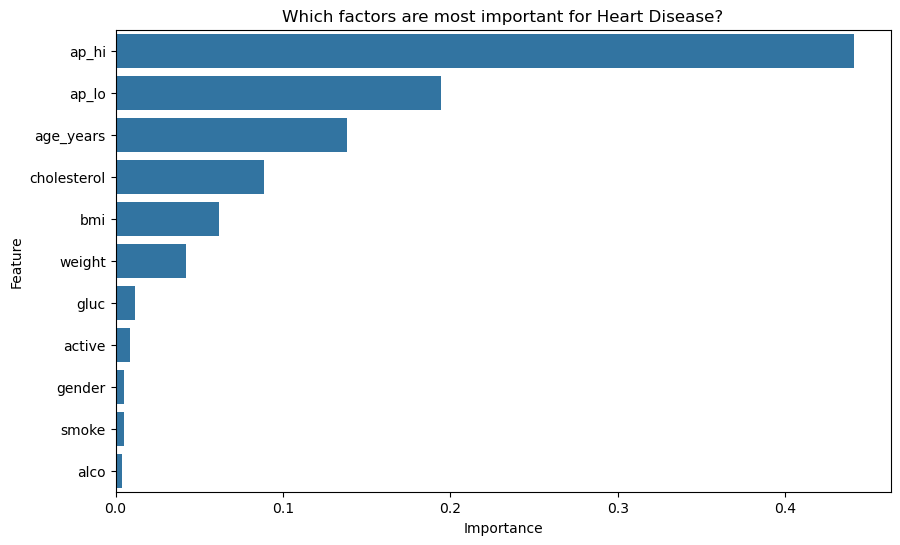

In [25]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances)
plt.title('Which factors are most important for Heart Disease?')
plt.show()

In [26]:
for i in y_pred:
    if i==0:
        print("yes");
    else:
        print('No');

yes
No
No
yes
yes
No
yes
No
yes
yes
yes
yes
yes
No
No
yes
yes
No
yes
No
yes
yes
yes
yes
No
No
No
No
yes
yes
yes
No
No
yes
yes
No
yes
yes
yes
yes
No
yes
yes
yes
yes
yes
No
yes
yes
yes
No
No
yes
yes
No
No
yes
yes
No
No
yes
No
yes
yes
yes
yes
yes
yes
No
No
No
yes
No
No
yes
yes
yes
No
No
yes
No
yes
yes
No
yes
No
yes
yes
yes
No
yes
No
No
yes
yes
yes
yes
yes
yes
No
yes
No
yes
yes
yes
No
yes
yes
No
No
yes
yes
No
yes
yes
No
yes
yes
No
No
No
No
No
No
yes
yes
yes
yes
No
yes
yes
No
yes
yes
No
No
No
yes
yes
yes
No
yes
No
yes
No
No
No
yes
yes
yes
yes
yes
No
No
No
yes
yes
No
yes
yes
yes
No
yes
yes
No
yes
yes
yes
yes
No
No
No
yes
No
No
yes
No
yes
yes
No
yes
yes
No
yes
yes
yes
No
No
No
No
No
No
No
yes
No
No
yes
No
yes
No
yes
yes
No
yes
yes
yes
No
No
yes
yes
yes
yes
No
No
yes
No
No
yes
yes
No
yes
No
No
yes
yes
yes
yes
yes
yes
No
No
yes
yes
yes
yes
No
yes
yes
No
yes
No
yes
yes
yes
yes
yes
No
yes
No
No
No
yes
No
No
No
No
No
yes
No
No
No
yes
yes
yes
yes
yes
No
yes
yes
No
No
yes
yes
yes
yes
yes
No
yes
yes


In [27]:
accuracy_score(y_test, y_pred)

0.736930246104558

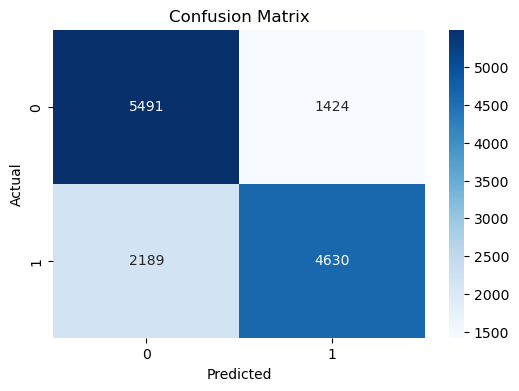

              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6915
           1       0.76      0.68      0.72      6819

    accuracy                           0.74     13734
   macro avg       0.74      0.74      0.74     13734
weighted avg       0.74      0.74      0.74     13734



In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print(classification_report(y_test, y_pred))

In [29]:
train_accuracy = accuracy_score(y_train, rf_model.predict(X_train))
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

if train_accuracy > test_accuracy + 0.10:
    print("Status: Overfitting")
elif train_accuracy < 0.60:
    print("Status: Underfitting")
else:
    print("Status: Good Fit")

Training Accuracy: 0.7548
Testing Accuracy: 0.7369
Status: Good Fit
